Recording Ground Truth and Track Trajectory

saved


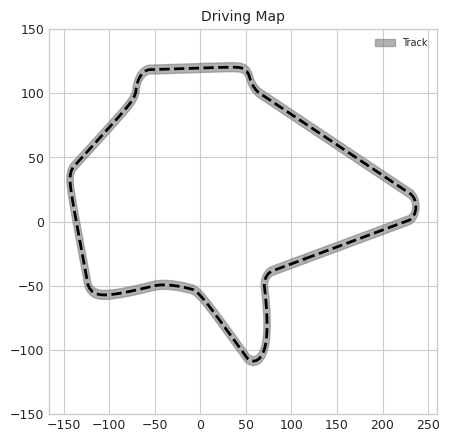

In [5]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from stable_baselines3 import PPO

STEPS = 860
MODEL_NAME = "Ground_Truth"
WEIGHTS_DIR = 'model_weights2'
TRACK_DIR = 'tracks'

#model loading
env = gym.make("CarRacing-v1", continuous=False)
model = PPO.load(f"{WEIGHTS_DIR}/ppo_5m.zip")
obs = env.reset(seed=42)

trajectory_x, trajectory_y, actions = [], [], []


for t in range(STEPS):
    # env.render()
    action, _ = model.predict(obs)
    obs, reward, done, info = env.step(action)
    pos = env.unwrapped.car.hull.position
    trajectory_x.append(float(pos.x))
    trajectory_y.append(float(pos.y))
    actions.append(int(action))

    if done:
        break

track = env.unwrapped.track
center_x = np.array([tile[2] for tile in track])
center_y = np.array([tile[3] for tile in track])

center_x = np.append(center_x, center_x[0])
center_y = np.append(center_y, center_y[0])

dx = np.gradient(center_x)
dy = np.gradient(center_y)

length = np.sqrt(dx**2 + dy**2)
length = np.maximum(length, 1e-8)  

dx /= length
dy /= length

nx = -dy
ny = dx

track_width = 7

left_x = center_x + nx * track_width / 2
left_y = center_y + ny * track_width / 2

right_x = center_x - nx * track_width / 2
right_y = center_y - ny * track_width / 2

env.close()


max_len = max(len(center_x),len(trajectory_x))

def pad(arr, length):
    arr = np.array(arr)
    if len(arr) < length:
        return np.pad(arr, (0, length - len(arr)), constant_values=np.nan)
    return arr[:length]

df = pd.DataFrame({
    "step": np.arange(max_len),

    "center_x": pad(center_x, max_len),
    "center_y": pad(center_y, max_len),

    "left_x": pad(left_x, max_len),
    "left_y": pad(left_y, max_len),

    "right_x": pad(right_x, max_len),
    "right_y": pad(right_y, max_len),

    f"{MODEL_NAME}_x": pad(trajectory_x, max_len),
    f"{MODEL_NAME}_y": pad(trajectory_y, max_len),

    f"{MODEL_NAME}_action": pad(actions, max_len),
})

df.to_csv(f"{TRACK_DIR}/record_{MODEL_NAME}.csv", index=False)
print('saved')

plt.figure(figsize=(5, 5))

plt.fill(
    np.concatenate([left_x, right_x[::-1]]),
    np.concatenate([left_y, right_y[::-1]]),
    color='gray',
    alpha=0.6,
    label="Track"
)

plt.plot(center_x, center_y, '--', color='black', linewidth=2)
# plt.plot(trajectory_x, trajectory_y, 'r', linewidth=2, label="Ground Truth")
plt.ylim(-150, 150)
plt.grid(True)
plt.legend()
plt.title("Driving Map")
plt.show()



Additionally, Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/waleed/.local/lib/python3.10/site-packages/tensorflow/__init__.py:30: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils as _distutils
2026-04-16 16:26:23.856397: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776327983.913174  398772 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has

Running: FLUID


<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
2026-04-16 16:26:29.865692: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


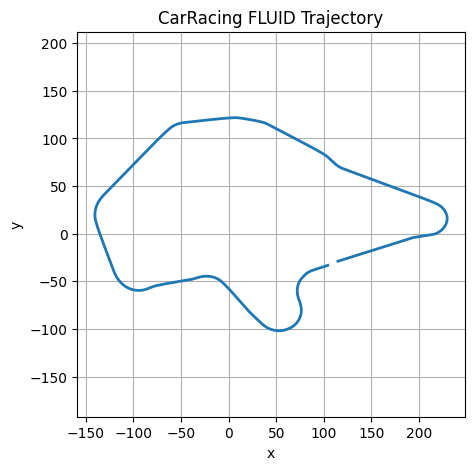

Running: ContiFormer


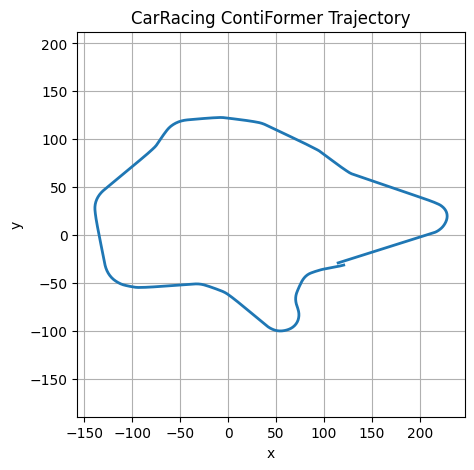

Running: ODEFormer


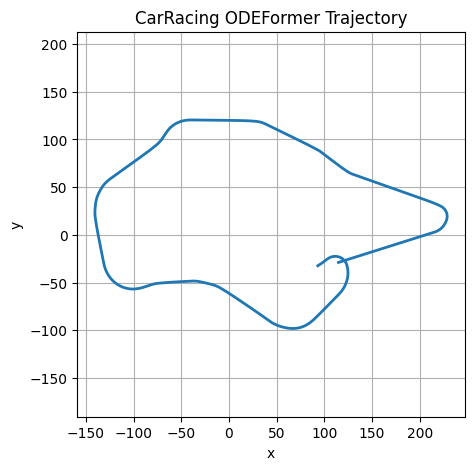

Running: OTTransformer


/home/waleed/.local/lib/python3.10/site-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


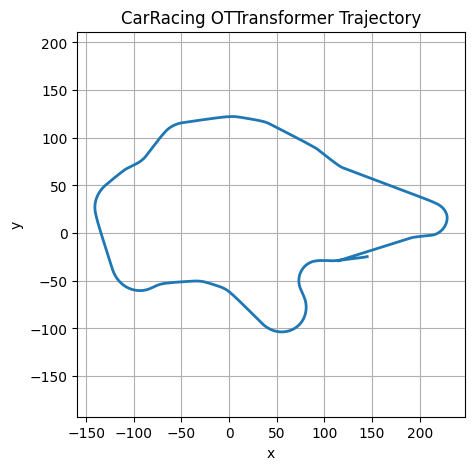

Running: SPDA


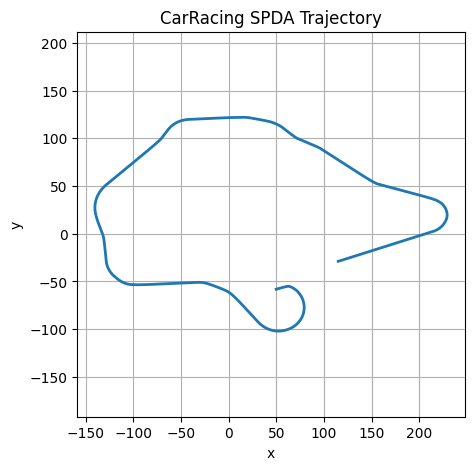

In [1]:
import gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout,
    TimeDistributed, Conv2D, GlobalMaxPooling1D, RNN
)
from tensorflow.keras.models import Model

from FLUID import FLUID
from neuronal_attention_circuit import NAC
from baseline_cells import ContiFormer, ODEformer, OTTransformer, CTRNNCell, SPDATransformer


STEPS = 782
WEIGHTS_DIR = "model_weights2"
TRACKS_DIR = "tracks"


def build_model(name, input_shape=(None, 96, 96, 3)):
    inp = Input(shape=input_shape)

    x = TimeDistributed(Conv2D(10, (3, 3), activation='relu', strides=2))(inp)
    x = TimeDistributed(Dropout(0.2))(x)
    x = TimeDistributed(Conv2D(20, (5, 5), activation='relu', strides=2))(x)
    x = TimeDistributed(Dropout(0.2))(x)
    x = TimeDistributed(Conv2D(30, (5, 5), activation='relu', strides=2))(x)
    x = TimeDistributed(Dropout(0.2))(x)
    x = TimeDistributed(Flatten())(x)

    if name == "FLUID":
        x = FLUID(d_model=64, num_heads=16, ff_dim=64, topk=16, max_len=5000)(x)
    elif name == "ContiFormer":
        x = Dense(64)(x)
        x = ContiFormer(dim=64, num_heads=16, ff_dim=64)(x)
    elif name == "ODEFormer":
        x = ODEformer(hidden_dim=64, num_heads=16, ff_dim=64)(x)
    elif name == "OTTransformer":
        x = OTTransformer(key_dim=64, num_heads=16, ff_dim=64)(x)
    elif name == "SPDA":
        x = SPDATransformer(embed_dim=64, num_heads=16, ff_dim=64)(x)
    # elif name == "CTRNN":
    #     RNN(CTRNNCell(units=64, method='euler', num_unfolds=5),return_sequences=True)(x)
    else:
        raise ValueError(f"Unknown model name: {name}")

    x = GlobalMaxPooling1D()(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(5, activation='softmax')(x)

    return Model(inp, out)


MODEL_LIST = ["FLUID", "ContiFormer", "ODEFormer", "OTTransformer", "SPDA"]

for name in MODEL_LIST:
    print(f"Running: {name}")

    env = gym.make("CarRacing-v1", continuous=False)
    model = build_model(name)
    model.load_weights(f"{WEIGHTS_DIR}/CarRacing_{name}.keras")

    obs = env.reset(seed=42)

    trajectory_x, trajectory_y, actions = [], [], []

    for _ in range(STEPS):
        # env.render()

        obs_input = np.expand_dims(np.expand_dims(np.array(obs), axis=0), axis=1)

        action_probs = model.predict(obs_input, verbose=0).squeeze()
        action = int(np.argmax(action_probs))
        obs, _, done, _ = env.step(action)

        pos = env.unwrapped.car.hull.position
        trajectory_x.append(float(pos.x))
        trajectory_y.append(float(pos.y))
        actions.append(action)

        if done:
            break

    env.close()

    df = pd.DataFrame({
        "step": np.arange(len(trajectory_x)),
        f"{name}_x": trajectory_x,
        f"{name}_y": trajectory_y,
        f"{name}_action": actions,
    })

    df.to_csv(f"{TRACKS_DIR}/record_{name}.csv", index=False)

    plt.figure(figsize=(5,5))
    plt.plot(trajectory_x, trajectory_y, linewidth=2)
    plt.title(f"CarRacing {name} Trajectory")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True)
    plt.show()



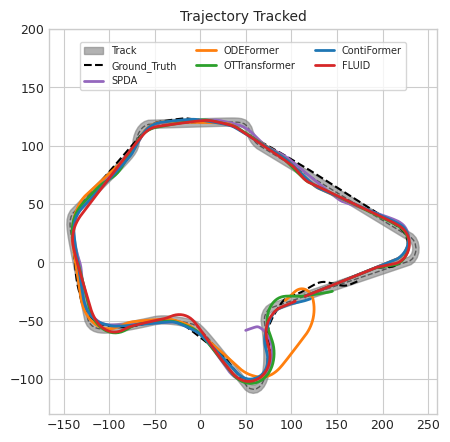

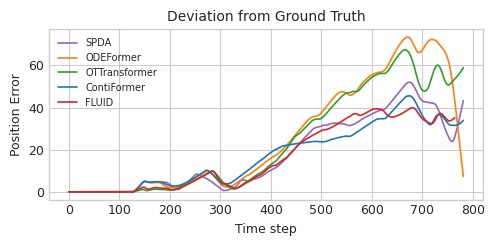

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

TRACK_DIR = "tracks"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
})

MODEL_LIST = ["Ground_Truth", "SPDA", "ODEFormer", "OTTransformer", "ContiFormer", "FLUID"]

COLOR_MAP = {
    "Ground_Truth": "black",
    "SPDA": "tab:purple",
    "ContiFormer": "tab:blue",
    "ODEFormer": "tab:orange",
    "OTTransformer": "tab:green",
    "FLUID": "tab:red",
}


# -------------------- TRACK --------------------
def extract_track(df):
    required = ["center_x", "center_y", "left_x", "left_y", "right_x", "right_y"]

    if not all(col in df.columns for col in required):
        return None

    return {
        "center_x": df["center_x"].values,
        "center_y": df["center_y"].values,
        "left_x": df["left_x"].values,
        "left_y": df["left_y"].values,
        "right_x": df["right_x"].values,
        "right_y": df["right_y"].values,
    }


# -------------------- TRAJECTORY --------------------
def extract_trajectory(df, x_col, y_col, label):
    if df is None:
        return None

    if x_col not in df.columns or y_col not in df.columns:
        return None

    return {
        "x": df[x_col].values,
        "y": df[y_col].values,
        "label": label
    }


def plot_error(trajectories):
    gt = next((t for t in trajectories if t["label"] == "Ground_Truth"), None)

    if gt is None:
        raise ValueError("Ground_Truth trajectory not found.")

    plt.figure(figsize=(5, 2.5))

    for traj in trajectories:
        if traj["label"] == "Ground_Truth":
            continue

        n = min(len(gt["x"]), len(traj["x"]))

        error = np.sqrt(
            (traj["x"][:n] - gt["x"][:n])**2 +
            (traj["y"][:n] - gt["y"][:n])**2
        )

        color = COLOR_MAP.get(traj["label"], None)
        plt.plot(error, label=traj["label"], color=color)

    plt.title("Deviation from Ground Truth")
    plt.xlabel("Time step")
    plt.ylabel("Position Error")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_scene(track, trajectories):
    if track is None:
        raise ValueError("Track data not found.")

    plt.figure(figsize=(5, 5))

    # track boundary
    plt.fill(
        np.concatenate([track["left_x"], track["right_x"][::-1]]),
        np.concatenate([track["left_y"], track["right_y"][::-1]]),
        color="gray",
        alpha=0.6,
        label="Track"
    )

    plt.plot(
        track["center_x"],
        track["center_y"],
        "--",
        color="black",
        linewidth=1,
        alpha=0.5
    )

    # trajectories
    for traj in trajectories:
        color = COLOR_MAP.get(traj["label"], None)

        if traj["label"] == "Ground_Truth":
            plt.plot(
                traj["x"], traj["y"],
                linestyle="--",
                linewidth=1.5,
                color=color,
                label=traj["label"]
            )
        else:
            plt.plot(
                traj["x"], traj["y"],
                linewidth=2,
                color=color,
                label=traj["label"]
            )

    plt.ylim(-130, 200)
    plt.grid(True)
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=3,   # adjust based on how many items you usually have
        frameon=True,
    )
    plt.title("Trajectory Tracked")
    # plt.tight_layout()
    plt.show()


trajectories = []
track = None

for name in MODEL_LIST:
    file_path = f"{TRACK_DIR}/record_{name}.csv"

    if not os.path.exists(file_path):
        print(f"Warning: missing file {file_path}, skipping.")
        continue

    df = pd.read_csv(file_path)

    if name == "Ground_Truth":
        track = extract_track(df)

    traj = extract_trajectory(df, f"{name}_x", f"{name}_y", name)

    if traj is not None:
        trajectories.append(traj)


# -------------------- PLOT --------------------
plot_scene(track, trajectories)
plot_error(trajectories)

Heatmaps

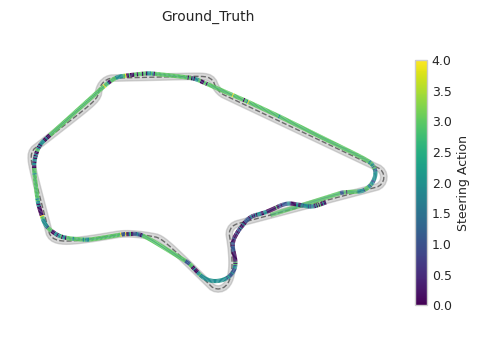

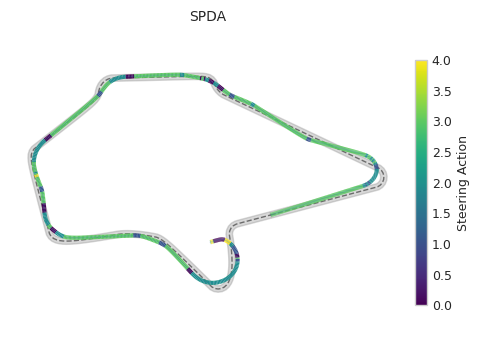

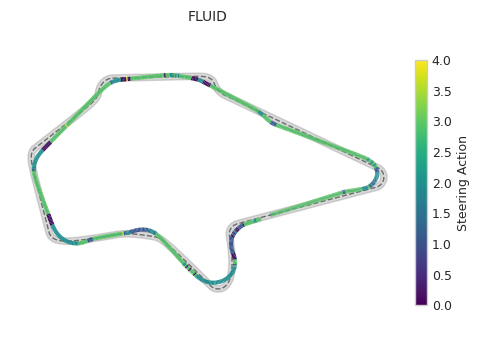

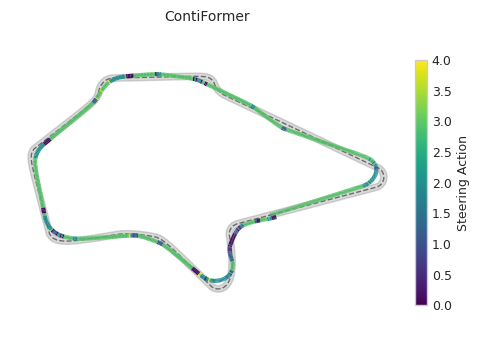

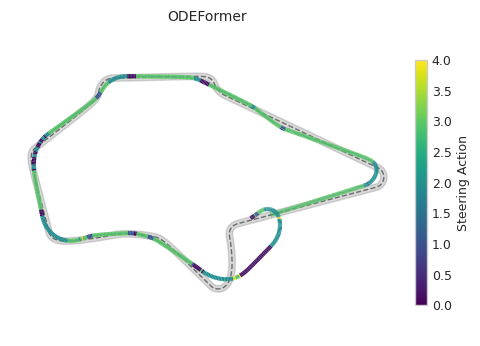

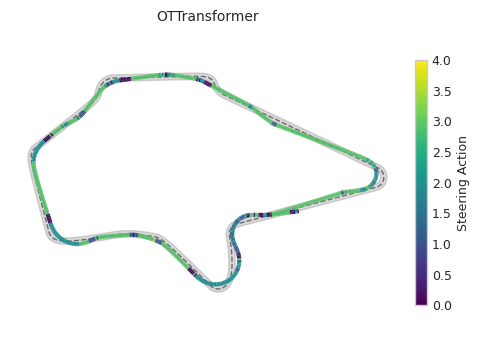

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

TRACK_DIR = "tracks"


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
})

def extract_track(df):
    return {
        "center_x": df["center_x"].values,
        "center_y": df["center_y"].values,
        "left_x": df["left_x"].values,
        "left_y": df["left_y"].values,
        "right_x": df["right_x"].values,
        "right_y": df["right_y"].values,
    }


def extract_trajectory(df, x_col, y_col, label):
    return {"x": df[x_col].values,"y": df[y_col].values,"label": label}


def plot_heatmap_line(x, y, values, cmap="viridis"):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments,cmap=cmap, norm=plt.Normalize(0, 4))
    lc.set_array(values[:-1])
    lc.set_linewidth(3)
    plt.gca().add_collection(lc)
    return lc


def plot_scene(track, traj, actions, title):
    plt.figure(figsize=(5, 3.5))

    plt.fill(
        np.concatenate([track["left_x"], track["right_x"][::-1]]),
        np.concatenate([track["left_y"], track["right_y"][::-1]]),
        color="gray",
        alpha=0.3)
    plt.plot(track["center_x"], track["center_y"],"--", color="black",linewidth=1,alpha=0.5)

    x, y = traj["x"], traj["y"]

    n = min(len(x), len(actions))
    x, y, actions = x[:n], y[:n], actions[:n]

    if n > 1:
        lc = plot_heatmap_line(x, y, actions)
        plt.colorbar(lc, label="Steering Action", shrink=0.8, aspect=20, pad=0.02)

    plt.plot(x, y, alpha=0.2)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.axis("equal")
    plt.title(title)
    plt.tight_layout()
    plt.show()


MODEL_LIST = ["Ground_Truth", "SPDA", "FLUID", "ContiFormer", "ODEFormer", "OTTransformer"]
track = None

for name in MODEL_LIST:
    df = pd.read_csv(f"{TRACK_DIR}/record_{name}.csv")

    if name == "Ground_Truth":
        track = extract_track(df)

    traj = extract_trajectory(df, f"{name}_x", f"{name}_y", name)
    actions = df[f"{name}_action"].values

    plot_scene(track, traj, actions, name)